T-test

In [1]:
import scipy.stats
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
sns.set()
from decodedoutputdefs import Precision, training_curve_indv, training_curve_average #class with the compiled definitions

In [2]:
def getfiles(base):
    files = os.listdir(base)
    files = [f for f in files if '.csv' in f]
    full_files = [base+f for f in files if 'EpcLog' not in f]
    print(len(full_files))
    return full_files

def geterror_array(base):
    full_files = getfiles(base)
    p = Precision()
    err = p.mult_models(full_files)
    return err

def stats_test(base,base2,experiment):
    chunk = base+"sir3_chunk/"+base2+"hybrid/"+experiment
    nochunk = base+"sir3/"+base2+experiment
    
    chunk_files = getfiles(chunk)
    chunk_errors = []
    for f in range(len(chunk_files)):
        p = Precision()
        err = p.mult_models([chunk_files[f]])
        chunk_errors.append(np.mean(np.abs(err)))
    
    nochunk_files = getfiles(nochunk)
    nochunk_errors = []
    for f in range(len(nochunk_files)):
        p = Precision()
        err = p.mult_models([nochunk_files[f]])
        nochunk_errors.append(np.mean(np.abs(err)))

    chunk_errors = np.array(chunk_errors)
    nochunk_errors = np.array(nochunk_errors)
    t = scipy.stats.ttest_ind(chunk_errors,nochunk_errors)
    return t

def percent_change(base,base2,experiment):
    sir2_file = base + "sir2_new/" +base2+experiment
    sir2_chunk_file = base + "sir2_chunk/" +base2+"hybrid/"+experiment
    sir3_file = base + "sir3/" +base2+experiment
    sir3_chunk_file = base + "sir3_chunk/" +base2+"hybrid/"+experiment
    
    sir2_chunk_files = getfiles(sir2_chunk_file)
    sir2_chunk_errors = []
    for f in range(len(sir2_chunk_files)):
        p = Precision()
        err = p.mult_models([sir2_chunk_files[f]])
        sir2_chunk_errors.append(np.mean(np.abs(err)))
        
    sir2_files = getfiles(sir2_file)
    sir2_errors = []
    for f in range(len(sir2_files)):
        p = Precision()
        err = p.mult_models([sir2_files[f]])
        sir2_errors.append(np.mean(np.abs(err)))
    
    sir3_chunk_files = getfiles(sir3_chunk_file)
    sir3_chunk_errors = []
    for f in range(len(sir3_chunk_files)):
        p = Precision()
        err = p.mult_models([sir3_chunk_files[f]])
        sir3_chunk_errors.append(np.mean(np.abs(err)))
    
    sir3_files = getfiles(sir3_file)
    sir3_errors = []
    for f in range(len(sir3_files)):
        p = Precision()
        err = p.mult_models([sir3_files[f]])
        sir3_errors.append(np.mean(np.abs(err)))
    

    sir2_chunk_errors = np.array(sir2_chunk_errors)
    sir3_chunk_errors = np.array(sir3_chunk_errors)
    sir2_errors = np.array(sir2_errors)
    sir3_errors = np.array(sir3_errors)
    task2_prct = []
    task3_prct = []
    for i in range(len(sir2_chunk_errors)):
        task2_prct.append((np.abs(sir2_chunk_errors[i]-sir2_errors[i])/sir2_errors[i])*100)
        task3_prct.append((np.abs(sir3_chunk_errors[i]-sir3_errors[i])/sir3_errors[i])*100)
    task2_mean = np.mean(np.array(task2_prct))
    task3_mean = np.mean(np.array(task2_prct))
    task2_errbar = np.sqrt(np.var(np.array(task2_prct))/len(task2_prct))
    task3_errbar = np.sqrt(np.var(np.array(task3_prct))/len(task3_prct))
    return task2_mean, task3_mean, task2_errbar, task3_errbar
        

In [3]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/sigma12/"
t = stats_test(base,base2,experiment)
print(t)

80
80
Ttest_indResult(statistic=-0.6254833425136198, pvalue=0.532556278595063)


In [4]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/"
t = stats_test(base,base2,experiment)
print(t)

80
80
Ttest_indResult(statistic=-1.9862732898657447, pvalue=0.04873253601988128)


In [4]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/"
t = stats_test(base,base2,experiment)
print(t)

80
80
Ttest_indResult(statistic=-1.9862732898657447, pvalue=0.04873253601988128)


In [12]:
sir2_file = base + "sir2_new/" +base2+experiment
sir2_chunk_file = base + "sir2_chunk/" +base2+"hybrid/"+experiment
sir3_file = base + "sir3/" +base2+experiment
sir3_chunk_file = base + "sir3_chunk/" +base2+"hybrid/"+experiment

sir2_chunk_files = getfiles(sir2_chunk_file)
sir2_chunk_errors = []
for f in range(len(sir2_chunk_files)):
    p = Precision()
    err = p.mult_models([sir2_chunk_files[f]])
    sir2_chunk_errors.append(np.mean(np.abs(err)))

sir2_files = getfiles(sir2_file)
sir2_errors = []
for f in range(len(sir2_files)):
    p = Precision()
    err = p.mult_models([sir2_files[f]])
    sir2_errors.append(np.mean(np.abs(err)))

sir3_chunk_files = getfiles(sir3_chunk_file)
sir3_chunk_errors = []
for f in range(len(sir3_chunk_files)):
    p = Precision()
    err = p.mult_models([sir3_chunk_files[f]])
    sir3_chunk_errors.append(np.mean(np.abs(err)))

sir3_files = getfiles(sir3_file)
sir3_errors = []
for f in range(len(sir3_files)):
    p = Precision()
    err = p.mult_models([sir3_files[f]])
    sir3_errors.append(np.mean(np.abs(err)))


sir2_chunk_errors = np.array(sir2_chunk_errors)
sir3_chunk_errors = np.array(sir3_chunk_errors)
sir2_errors = np.array(sir2_errors)
sir3_errors = np.array(sir3_errors)
task2_prct = []
task3_prct = []

80
80
80
80


In [24]:
    for i in range(len(sir2_chunk_errors)):
        task2_prct.append((np.abs(sir2_chunk_errors[i]-sir2_errors[i])/sir2_errors[i]))
        task3_prct.append((np.abs(sir3_chunk_errors[i]-sir3_errors[i])/sir3_errors[i]))
    task2_mean = np.mean(np.array(task2_prct))*100
    task3_mean = np.mean(np.array(task2_prct))*100
    task2_errbar = np.sqrt(np.var(np.array(task2_prct))/len(task2_prct))
    task3_errbar = np.sqrt(np.var(np.array(task3_prct))/len(task3_prct))

In [33]:
((sir2_chunk_errors-sir2_errors)/sir2_errors)*100

array([ 614.73091333,   53.08645634,  -32.97388681,  -68.76516541,
         79.41582008,  -90.34611925, 1268.77984603,  -88.74779656,
        -84.07315784,   46.37047221,  -90.54080605,  -32.56224513,
         96.53832319,   79.43585761,   49.03208305,   47.24389837,
        -88.2222939 ,   54.9143569 , 2646.90460565,   48.64319848,
        115.94342314,  -69.65874691,   84.39144174,   76.60496471,
          8.78033919,   58.17537097,  -89.73745966,  -30.07391736,
         49.57933677, 1694.50718632,   65.34284937,  174.69566012,
        -41.72215216,  -73.43138153,   52.45320716,   71.43550332,
        -86.18703335,   44.14136309,   74.7585231 ,   77.8076138 ,
        -89.06843031,  -72.43613393, 1503.21815821,  -90.00866815,
        -15.34047309,  -29.79788193,  -42.1241866 ,   72.40308262,
         74.33997873,   74.09340881,   -7.42087818,   73.07994785,
        -26.90697482,  -81.55249459,   62.0053007 ,  142.56581789,
         41.01211172,   76.70225502,  -79.00727252,  -75.10558

In [30]:
np.mean(((sir2_chunk_errors-sir2_errors)/sir2_errors)*100)

136.73413752037624

In [34]:
np.mean(((sir3_chunk_errors-sir3_errors)/sir3_errors)*100)

0.2069893812271532

In [35]:
(np.mean(sir2_chunk_errors)-np.mean(sir2_errors))/np.mean(sir2_errors)

-0.14328959826990248

In [36]:
(np.mean(sir3_chunk_errors)-np.mean(sir3_errors))/np.mean(sir3_errors)

-0.08079407818426221

In [23]:
np.abs(np.mean(sir3_chunk_errors) - np.mean(sir3_errors))/np.mean(sir3_errors)*100

8.07940781842622

In [16]:
np.mean(sir3_chunk_errors)

53.81302911130781

In [17]:
np.mean(sir3_errors)

58.54295303603915

In [21]:
np.mean(sir2_chunk_errors)

9.8713861031404

In [9]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/"
task2_mean, task3_mean, task2_errbar, task3_errbar = percent_change(base,base2,experiment)

80
80
80
80


<BarContainer object of 2 artists>

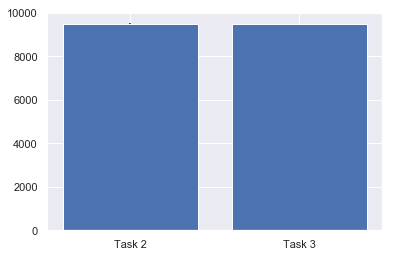

In [25]:
plt.bar(['Task 2', 'Task 3'], [task2_mean, task3_mean], yerr = [task2_errbar, task3_errbar])